<a href="https://colab.research.google.com/github/PappuBaraf/PappuBaraf/blob/main/Diabetes_Dataset_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Intercept: [-8.66264632]
Coefficients: [[ 0.04034995 -0.00167267  0.09637425]]

Predicted Probabilities:
[[0.85188149 0.14811851]
 [0.6688285  0.3311715 ]
 [0.79191789 0.20808211]
 [0.87808242 0.12191758]
 [0.57284377 0.42715623]
 [0.76693778 0.23306222]
 [0.98127307 0.01872693]
 [0.66468718 0.33531282]
 [0.41168525 0.58831475]
 [0.37364565 0.62635435]
 [0.82251931 0.17748069]
 [0.13517068 0.86482932]
 [0.5608961  0.4391039 ]
 [0.84063301 0.15936699]
 [0.91694808 0.08305192]
 [0.66573923 0.33426077]
 [0.84397788 0.15602212]
 [0.91688891 0.08311109]
 [0.18870864 0.81129136]
 [0.29433084 0.70566916]
 [0.84431268 0.15568732]
 [0.89613489 0.10386511]
 [0.70229577 0.29770423]
 [0.85004432 0.14995568]
 [0.55026302 0.44973698]
 [0.10128477 0.89871523]
 [0.86473013 0.13526987]
 [0.94402759 0.05597241]
 [0.5896803  0.4103197 ]
 [0.90753491 0.09246509]
 [0.05552016 0.94447984]
 [0.28113172 0.71886828]
 [0.13420716 0.86579284]
 [0.23349449 0.76650551]
 [0.53726114 0.46273886]
 [0.38212978 0.61787

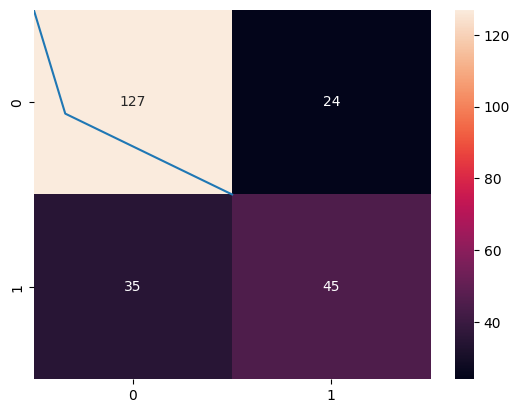

In [19]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc


data = pd.read_csv("/content/diabetes.csv")

x = data[["Glucose", "Insulin", "BMI"]]
y = data["Outcome"]

train_x, test_x, train_y, test_y = train_test_split(
    x, y, test_size=0.3, random_state=42
)

model = LogisticRegression(max_iter=1000)
model.fit(train_x, train_y)

print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

print("\nPredicted Probabilities:")
print(model.predict_proba(test_x))

pred_y = model.predict(test_x)

print("\nPredicted Values:")
print(pred_y)

print("\nConfusion Matrix:")
print(confusion_matrix(test_y, pred_y))

print("\nAccuracy:")
print(accuracy_score(test_y, pred_y))

c = confusion_matrix(test_y, pred_y)
sns.heatmap(c, annot=True, fmt="d")
x1= sm.add_constant(train_x)
log_reg = sm.Logit(train_y, x1)
result = log_reg.fit()
print(result.summary())

fpr,tpr,threshold = roc_curve(test_y, pred_y)
roc_auc = auc(fpr,tpr)
print(roc_auc)
plt.plot(fpr,tpr)
plt.show()